<a href="https://colab.research.google.com/github/oumaimabelgaied/DL_Labs/blob/main/TP2_DNN_OumaimaBelgaied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP N°2 : Classification avec des réseaux de neurones entièrement connectés
densely-connected NN

### **réalisée par** : Oumaima Belgaied

##I.Classification binaire

(1000, 2)
(1000,)


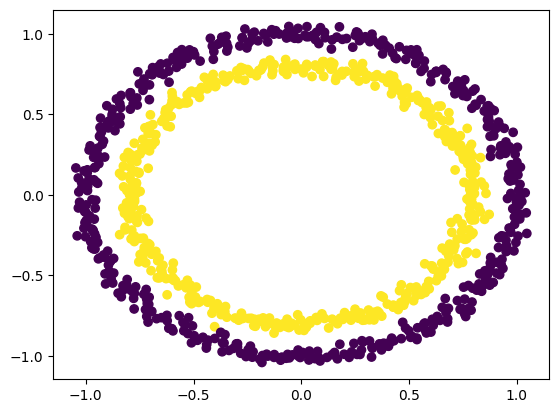

In [ ]:
from sklearn.datasets import make_circles
import numpy as np
import matplotlib.pyplot as plt

X,Y=make_circles(n_samples=1000 , noise=0.03)
print(X.shape) #dimensions input
print(Y.shape) #dimensions output

plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()


Ce dataset nécessite une fonction linéaire ou non linéaire pour séparer ses classes ? Justifier.

--> les données de ce dataset ne sont pas linéairement séparable et donc nécessite une fonction non linéaire pour capturer cet aspect.

In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    train_size=0.8,
    test_size=0.2,
    random_state=42
)

# 1) Définition du modèle
model = Sequential()
model.add(Dense(100, activation='relu', input_dim=2))  # couche cachée
model.add(Dense(1, activation='sigmoid')) # couche de sortie
model.summary()

# 2) Compilation du modèle
model.compile(
    optimizer='sgd', #màj des poids
    loss='binary_crossentropy', #calcul d'erreur
    metrics=['accuracy']
)

# 3) entraîner le modèle
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=0  # on désactive l'affichage par défaut
)

for i in range(0, 100, 10):
    train_loss = history.history['loss'][i]
    train_acc = history.history['accuracy'][i]
    test_loss = history.history['val_loss'][i]
    test_acc = history.history['val_accuracy'][i]
    print(f"Epoch {i+1:3d} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch   1 | Train Loss: 0.6926, Train Acc: 0.4888 | Test Loss: 0.6909, Test Acc: 0.4750
Epoch  11 | Train Loss: 0.6883, Train Acc: 0.5125 | Test Loss: 0.6931, Test Acc: 0.4500
Epoch  21 | Train Loss: 0.6850, Train Acc: 0.5125 | Test Loss: 0.6933, Test Acc: 0.4500
Epoch  31 | Train Loss: 0.6820, Train Acc: 0.5175 | Test Loss: 0.6923, Test Acc: 0.4650
Epoch  41 | Train Loss: 0.6791, Train Acc: 0.5512 | Test Loss: 0.6909, Test Acc: 0.4900
Epoch  51 | Train Loss: 0.6762, Train Acc: 0.6263 | Test Loss: 0.6890, Test Acc: 0.5600
Epoch  61 | Train Loss: 0.6733, Train Acc: 0.6700 | Test Loss: 0.6869, Test Acc: 0.5850
Epoch  71 | Train Loss: 0.6703, Train Acc: 0.6762 | Test Loss: 0.6843, Test Acc: 0.5900
Epoch  81 | Train Loss: 0.6671, Train Acc: 0.6850 | Test Loss: 0.6815, Test Acc: 0.5950
Epoch  91 | Train Loss: 0.6640, Train Acc: 0.6938 | Test Loss: 0.6788, Test Acc: 0.6100


4) Evaluer le modèle    

1646/1646 ━━━━━━━━━━━━━━━━━━━━ 2s 986us/step


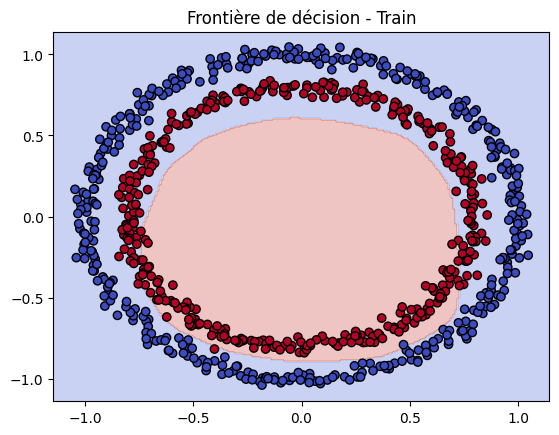

1604/1604 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


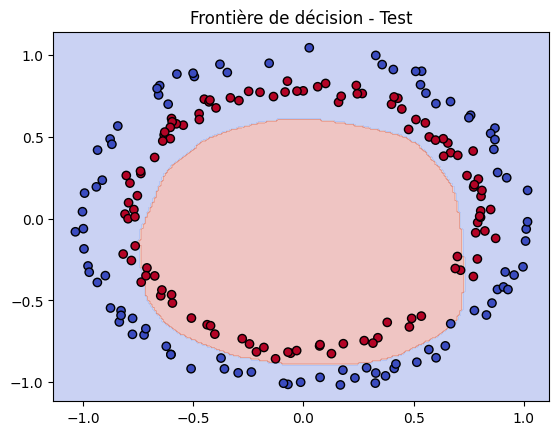

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_decision_boundary(model, X, y, title):
    # Création d'une grille couvrant les données
    x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
    y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Prédiction pour chaque point de la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int)  # seuil 0.5 pour classification binaire
    Z = Z.reshape(xx.shape)

    # Tracé
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title(title)
    plt.show()

# Frontières pour les ensembles train et test
plot_decision_boundary(model, X_train, Y_train, "Frontière de décision - Train")
plot_decision_boundary(model, X_test, Y_test, "Frontière de décision - Test")

Même avec un réseau simple (1 couche cachée + 100 neurones) et SGD, tu peux rencontrer :

* Convergence lente → SGD sans momentum ou learning rate faible prend beaucoup d’époques pour réduire la loss.

* Overfitting ou underfitting → si le réseau n’a pas assez de neurones ou pas assez de couches, il peut mal capturer la frontière non linéaire.

Conclusion : le modèle peut échouer à parfaitement séparer les cercles, surtout sur le test set.

omment améliorer les performances ?  Voici trois approches courantes :

1. Optimiseur + learning rate

* Remplacer SGD par Adam → converge plus vite.

* Ajuster le learning rate pour accélérer l’apprentissage.

2. Réseau plus profond

* Ajouter une 2ᵉ couche cachée ou plus de neurones → mieux capturer les frontières non linéaires.

3. Régularisation

* Ajouter Dropout pour éviter l’overfitting si le réseau devient trop grand.

* Normaliser les entrées → StandardScaler pour des valeurs centrées.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1646/1646 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


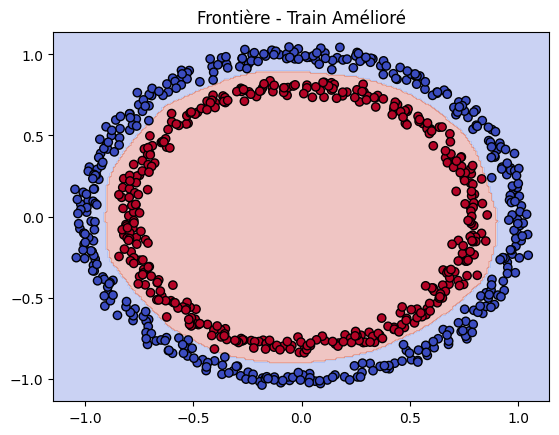

1604/1604 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


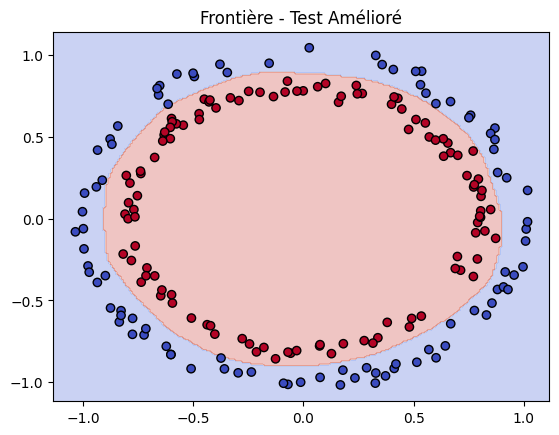

In [ ]:
from keras.layers import Dropout
from keras.optimizers import Adam

# Nouveau modèle
model_improved = Sequential()
model_improved.add(Dense(128, activation='relu', input_dim=2))
model_improved.add(Dense(64, activation='relu'))
model_improved.add(Dense(1, activation='sigmoid'))

# Compilation avec Adam
model_improved.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entraînement
history_improved = model_improved.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=0
)

# Tracer les frontières
plot_decision_boundary(model_improved, X_train, Y_train, "Frontière - Train Amélioré")
plot_decision_boundary(model_improved, X_test, Y_test, "Frontière - Test Amélioré")

##II. Multi-Classification

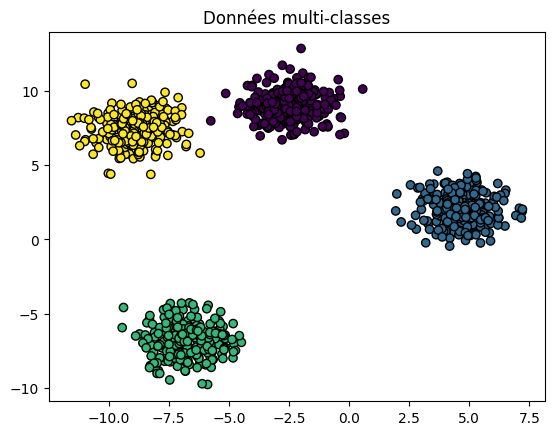

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Création du dataset
X, y = make_blobs(
    n_samples=1000,     # nombre d'échantillons
    n_features=2,       # nombre de features
    centers=4,          # nombre de classes
    cluster_std=1.0,    # écart-type des clusters
    random_state=42
)

# Visualisation rapide
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolor='k')
plt.title("Données multi-classes")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linéarite ? Les clusters sont globalement séparés, mais les frontières entre certains clusters peuvent ne pas être parfaitement linéaires. Donc une fonction non linéaire (MLP ou réseau Fully Connected) sera plus efficace que la régression logistique simple pour capturer toutes les classes.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=2))  # couche cachée
model.add(Dense(32, activation='relu'))               # deuxième couche cachée
model.add(Dense(4, activation='softmax'))             # couche de sortie 4 classes

# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # pour labels entiers
    metrics=['accuracy']
)

In [ ]:
# entraînement

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

# Affichage toutes les 10 époques
for i in range(0, 50, 10):
    train_loss = history.history['loss'][i]
    train_acc = history.history['accuracy'][i]
    val_loss = history.history['val_loss'][i]
    val_acc = history.history['val_accuracy'][i]
    print(f"Epoch {i+1:3d} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {val_loss:.4f}, Test Acc: {val_acc:.4f}")

Epoch   1 | Train Loss: 0.0023, Train Acc: 0.9987 | Test Loss: 0.0003, Test Acc: 1.0000
Epoch  11 | Train Loss: 0.0018, Train Acc: 0.9987 | Test Loss: 0.0009, Test Acc: 1.0000
Epoch  21 | Train Loss: 0.0019, Train Acc: 0.9987 | Test Loss: 0.0002, Test Acc: 1.0000
Epoch  31 | Train Loss: 0.0012, Train Acc: 1.0000 | Test Loss: 0.0016, Test Acc: 1.0000
Epoch  41 | Train Loss: 0.0018, Train Acc: 0.9987 | Test Loss: 0.0003, Test Acc: 1.0000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Prédictions sur le test set
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)  # softmax -> classes

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)
print("Matrice de confusion :\n", cm)

# Rapport classification
report = classification_report(y_test, y_pred_classes)
print("Rapport de classification :\n", report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Matrice de confusion :
 [[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 0  0  0 57]]
Rapport de classification :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



* Précision (precision) : % des prédictions correctes parmi toutes celles prédites pour une classe

* Rappel (recall) : % des vrais labels correctement prédits

* F1-score : moyenne harmonique de précision et rappel → balance entre les deux utilisé quand les échantillons sont mal-équilibrés

* Matrice de confusion : montre les vrais positifs et les erreurs par classe

159917/159917 ━━━━━━━━━━━━━━━━━━━━ 178s 1ms/step


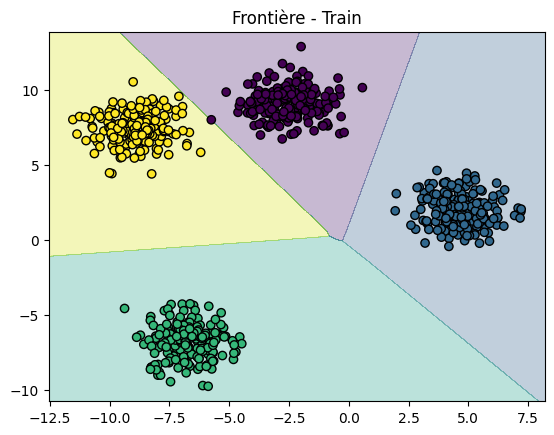

134084/134084 ━━━━━━━━━━━━━━━━━━━━ 150s 1ms/step


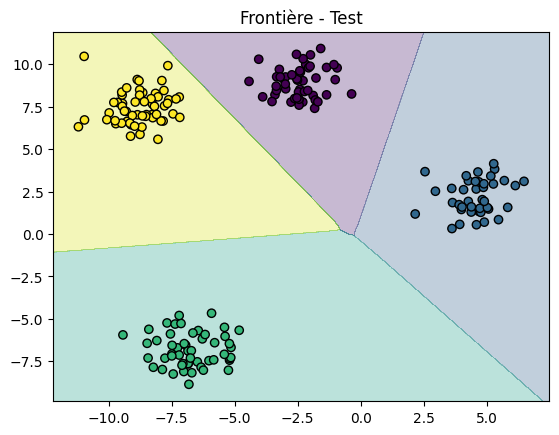

In [ ]:
def plot_decision_boundary_multiclass(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.argmax(axis=1)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap='viridis')
    plt.title(title)
    plt.show()

plot_decision_boundary_multiclass(model, X_train, y_train, "Frontière - Train")
plot_decision_boundary_multiclass(model, X_test, y_test, "Frontière - Test")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


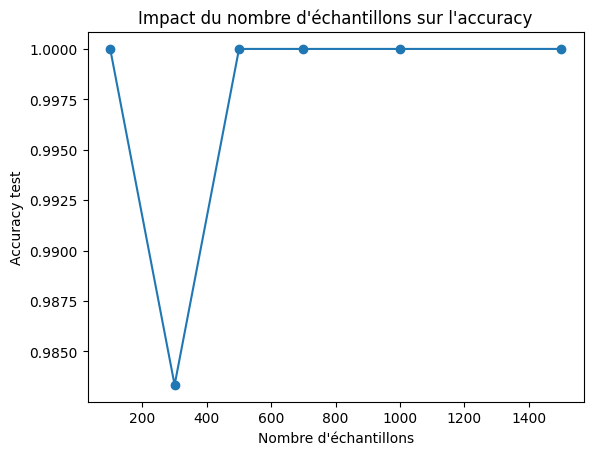

In [ ]:
sample_sizes = [100, 300, 500, 700, 1000, 1500]
train_acc_list = []

for n in sample_sizes:
    X_tmp, y_tmp = make_blobs(n_samples=n, n_features=2, centers=4, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42)

    tmp_model = Sequential([
        Dense(64, activation='relu', input_dim=2),
        Dense(32, activation='relu'),
        Dense(4, activation='softmax')
    ])
    tmp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    tmp_model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0)

    _, acc = tmp_model.evaluate(X_te, y_te, verbose=0)
    train_acc_list.append(acc)

# Tracer la progression de l'accuracy
plt.plot(sample_sizes, train_acc_list, marker='o')
plt.xlabel("Nombre d'échantillons")
plt.ylabel("Accuracy test")
plt.title("Impact du nombre d'échantillons sur l'accuracy")
plt.show()

Stabilisation après ~500 échantillons

Plus de points → meilleure représentation de chaque classe → accuracy très stable à 1.0.

**Surapprentissage (Overfitting) :** Avec un petit nombre d'échantillons, le modèle peut sur-apprendre et montrer une haute précision d'entraînement mais une mauvaise précision dans le test.

**Sous-apprentissage (Underfitting) :** Avec plus d'échantillons, le modèle montre une baisse de performance, indiquant un sous-apprentissage.